# CardioIA - Análise Inteligente de Sinais Cardíacos
print("CardioIA - Monitoramento Cardíaco IoT")
print("Análise de dados, detecção de anomalias e visualizações")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
np.random.seed(42)
n_amostras = 100
base_ts = int(pd.Timestamp.now().timestamp() * 1000)
registros = []

for i in range(n_amostras):
    bpm = int(np.random.normal(78, 15))
    if np.random.random() < 0.1:
        bpm = int(np.random.uniform(122, 145))

    temp = round(float(np.random.normal(36.4, 0.7)), 1)
    if np.random.random() < 0.06:
        temp = round(float(np.random.uniform(38.1, 39.8)), 1)

    registros.append({
        'timestamp': base_ts - i * 5000,
        'paciente_id': 'PAC-0001',
        'temperatura': temp,
        'umidade': int(np.random.uniform(50, 85)),
        'bpm': max(40, min(190, bpm)),
        'conectado': bool(np.random.choice([True, True, True, False]))
    })

df = pd.DataFrame(registros)
df['data_hora'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.sort_values('data_hora')
print(f"✅ Gerados {len(df)} registros simulados")
print(f"Período: {df['data_hora'].min()} até {df['data_hora'].max()}")
df.head(10)

✅ Gerados 100 registros simulados
Período: 2026-05-18 21:04:45.802000 até 2026-05-18 21:13:00.802000


,timestamp,paciente_id,temperatura,umidade,bpm,conectado,data_hora
99,1779138285802,PAC-0001,36.4,75,77,True,2026-05-18 21:04:45.802
98,1779138290802,PAC-0001,36.0,57,90,True,2026-05-18 21:04:50.802
97,1779138295802,PAC-0001,35.8,66,72,True,2026-05-18 21:04:55.802
96,1779138300802,PAC-0001,36.0,57,124,True,2026-05-18 21:05:00.802
95,1779138305802,PAC-0001,36.4,78,85,True,2026-05-18 21:05:05.802
94,1779138310802,PAC-0001,35.7,81,83,True,2026-05-18 21:05:10.802
93,1779138315802,PAC-0001,36.0,68,60,True,2026-05-18 21:05:15.802
92,1779138320802,PAC-0001,37.0,84,77,True,2026-05-18 21:05:20.802
91,1779138325802,PAC-0001,37.8,68,47,True,2026-05-18 21:05:25.802
90,1779138330802,PAC-0001,35.2,81,93,False,2026-05-18 21:05:30.802


In [3]:
print("=" * 50)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 50)
display(df[['bpm', 'temperatura', 'umidade']].describe())

print(f"\n📍 Valores nulos: {df.isnull().sum().sum()}")
print(f"📍 Pacientes únicos: {df['paciente_id'].nunique()}")
print(f"📍 Tempo conectado: {df['conectado'].mean()*100:.1f}%")

ESTATÍSTICAS DESCRITIVAS


,bpm,temperatura,umidade
count,100.000000,100.000000,100.000000
mean,84.100000,36.392000,67.850000
std,23.789693,0.774816,9.978133
min,40.000000,35.000000,50.000000
25%,69.750000,36.000000,58.750000
50%,81.000000,36.300000,68.000000
75%,93.000000,36.800000,76.000000
max,144.000000,39.800000,84.000000



📍 Valores nulos: 0
📍 Pacientes únicos: 1
📍 Tempo conectado: 75.0%


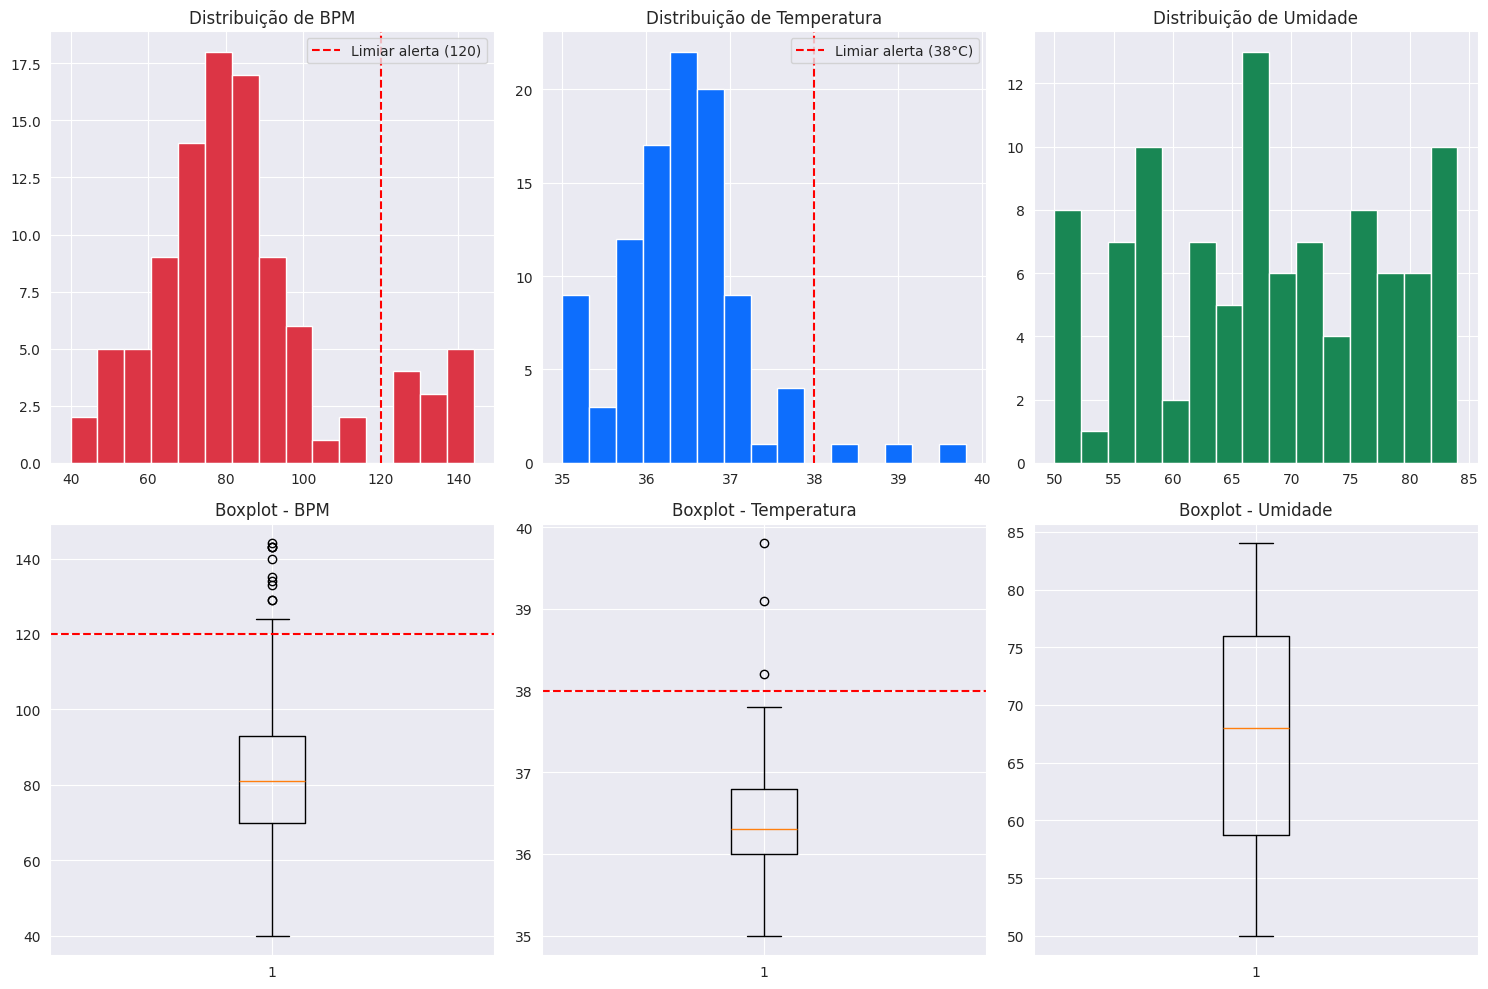

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].hist(df['bpm'], bins=15, color='#dc3545', edgecolor='white')
axes[0,0].set_title('Distribuição de BPM')
axes[0,0].axvline(120, color='red', ls='--', label='Limiar alerta (120)')
axes[0,0].legend()

axes[0,1].hist(df['temperatura'], bins=15, color='#0d6efd', edgecolor='white')
axes[0,1].set_title('Distribuição de Temperatura')
axes[0,1].axvline(38, color='red', ls='--', label='Limiar alerta (38°C)')
axes[0,1].legend()

axes[0,2].hist(df['umidade'], bins=15, color='#198754', edgecolor='white')
axes[0,2].set_title('Distribuição de Umidade')

axes[1,0].boxplot(df['bpm'])
axes[1,0].set_title('Boxplot - BPM')
axes[1,0].axhline(120, color='red', ls='--')

axes[1,1].boxplot(df['temperatura'])
axes[1,1].set_title('Boxplot - Temperatura')
axes[1,1].axhline(38, color='red', ls='--')

axes[1,2].boxplot(df['umidade'])
axes[1,2].set_title('Boxplot - Umidade')

plt.tight_layout()
plt.show()

In [5]:
print("=" * 50)
print("DETECÇÃO DE ANOMALIAS")
print("=" * 50)

# Z-Score para BPM
df['zscore_bpm'] = (df['bpm'] - df['bpm'].mean()) / df['bpm'].std()
df['anomalia_bpm'] = abs(df['zscore_bpm']) > 2

# IQR para Temperatura
q1_temp, q3_temp = df['temperatura'].quantile([0.25, 0.75])
iqr_temp = q3_temp - q1_temp
df['anomalia_temp'] = (df['temperatura'] < q1_temp - 1.5*iqr_temp) | (df['temperatura'] > q3_temp + 1.5*iqr_temp)

# Anomalia geral
df['anomalia'] = df['anomalia_bpm'] | df['anomalia_temp']

print(f"Total de anomalias: {df['anomalia'].sum()} de {len(df)} registros ({df['anomalia'].sum()/len(df)*100:.1f}%)")
print(f"  - BPM anômalo (Z-Score): {df['anomalia_bpm'].sum()}")
print(f"  - Temperatura anômala (IQR): {df['anomalia_temp'].sum()}")

alertas_bpm_regra = (df['bpm'] > 120).sum()
alertas_temp_regra = (df['temperatura'] > 38.0).sum()
print(f"\n📢 Alertas clínicos:")
print(f"  - BPM > 120: {alertas_bpm_regra}")
print(f"  - Temperatura > 38°C: {alertas_temp_regra}")

anomalias = df[df['anomalia']][['data_hora', 'bpm', 'temperatura', 'umidade', 'anomalia_bpm', 'anomalia_temp']]
display(anomalias)

DETECÇÃO DE ANOMALIAS
Total de anomalias: 11 de 100 registros (11.0%)
  - BPM anômalo (Z-Score): 8
  - Temperatura anômala (IQR): 3

📢 Alertas clínicos:
  - BPM > 120: 12
  - Temperatura > 38°C: 3


,data_hora,bpm,temperatura,umidade,anomalia_bpm,anomalia_temp
76,2026-05-18 21:06:40.802,134,36.4,68,True,False
70,2026-05-18 21:07:10.802,144,36.6,62,True,False
57,2026-05-18 21:08:15.802,143,36.8,68,True,False
48,2026-05-18 21:09:00.802,51,38.2,78,False,True
46,2026-05-18 21:09:10.802,85,39.1,74,False,True
29,2026-05-18 21:10:35.802,143,37.2,68,True,False
28,2026-05-18 21:10:40.802,135,36.0,50,True,False
22,2026-05-18 21:11:10.802,133,36.6,57,True,False
12,2026-05-18 21:12:00.802,140,36.8,75,True,False
5,2026-05-18 21:12:35.802,143,37.7,63,True,False


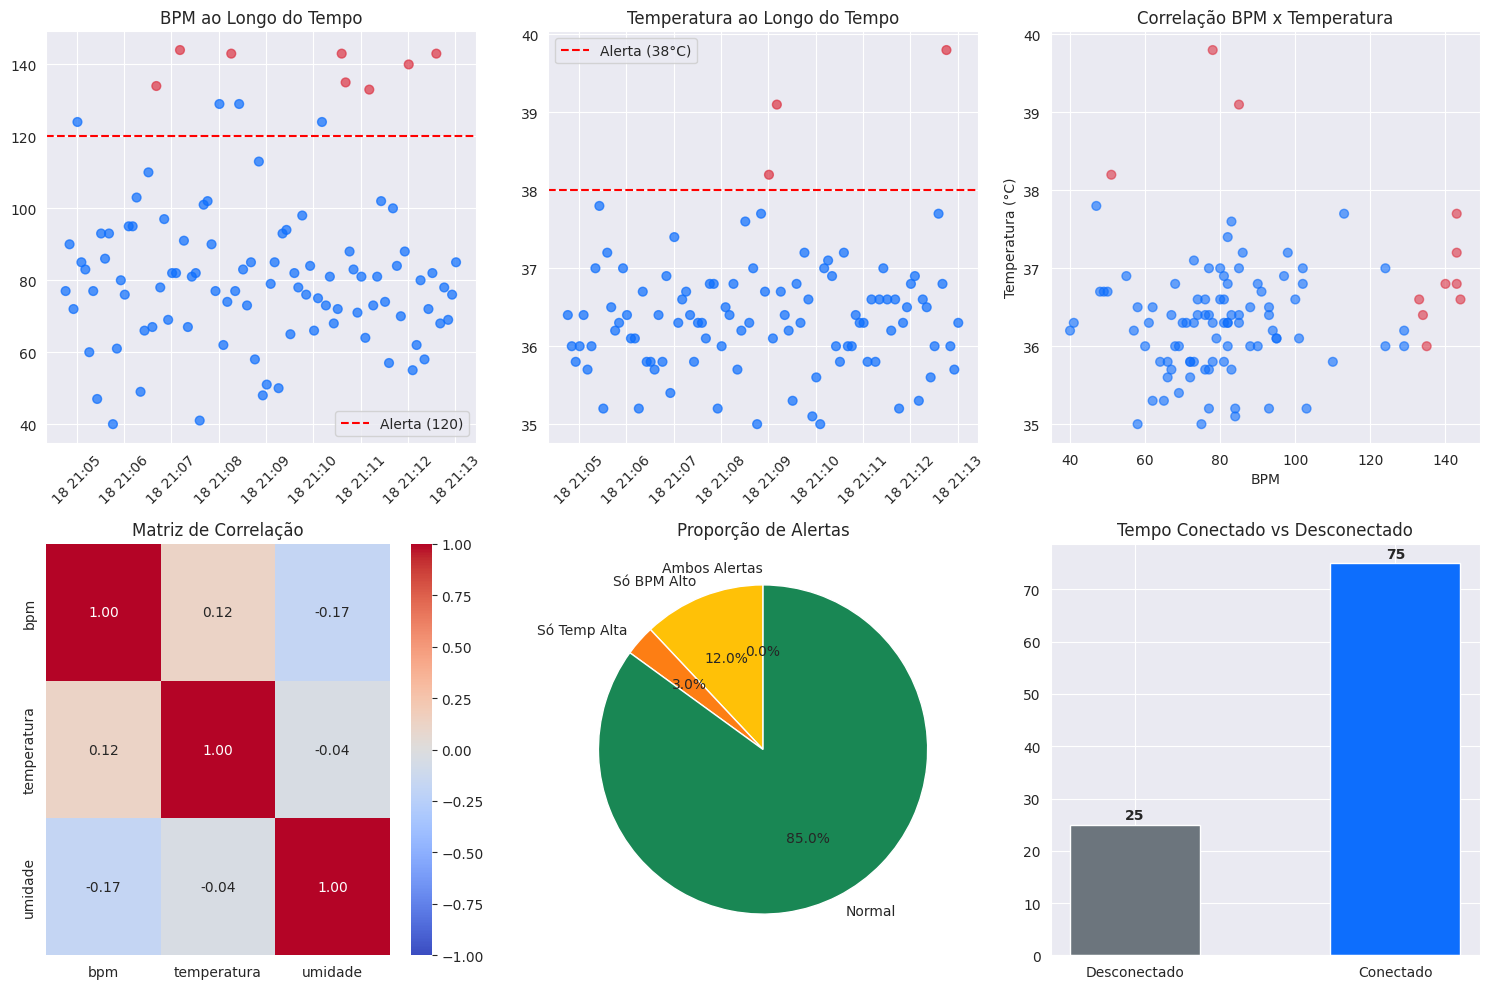

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Gráfico 1 - BPM ao longo do tempo
cores_bpm = ['#dc3545' if a else '#0d6efd' for a in df['anomalia_bpm']]
axes[0,0].scatter(df['data_hora'], df['bpm'], c=cores_bpm, alpha=0.7, s=40)
axes[0,0].axhline(120, color='red', ls='--', label='Alerta (120)')
axes[0,0].set_title('BPM ao Longo do Tempo')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Gráfico 2 - Temperatura ao longo do tempo
cores_temp = ['#dc3545' if a else '#0d6efd' for a in df['anomalia_temp']]
axes[0,1].scatter(df['data_hora'], df['temperatura'], c=cores_temp, alpha=0.7, s=40)
axes[0,1].axhline(38, color='red', ls='--', label='Alerta (38°C)')
axes[0,1].set_title('Temperatura ao Longo do Tempo')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# Gráfico 3 - Correlação BPM x Temperatura
axes[0,2].scatter(df['bpm'], df['temperatura'],
                  c=['#dc3545' if a else '#0d6efd' for a in df['anomalia']], alpha=0.6, s=40)
axes[0,2].set_xlabel('BPM')
axes[0,2].set_ylabel('Temperatura (°C)')
axes[0,2].set_title('Correlação BPM x Temperatura')

# Gráfico 4 - Matriz de correlação
corr = df[['bpm', 'temperatura', 'umidade']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,0], vmin=-1, vmax=1, center=0)
axes[1,0].set_title('Matriz de Correlação')

# Gráfico 5 - Pizza de alertas
cond_bpm_alto = df['bpm'] > 120
cond_temp_alta = df['temperatura'] > 38.0
ambos = (cond_bpm_alto & cond_temp_alta).sum()
s_bpm = (cond_bpm_alto & ~cond_temp_alta).sum()
s_temp = (~cond_bpm_alto & cond_temp_alta).sum()
normal = len(df) - ambos - s_bpm - s_temp

categorias = ['Ambos Alertas', 'Só BPM Alto', 'Só Temp Alta', 'Normal']
valores = [ambos, s_bpm, s_temp, normal if normal > 0 else 0]
cores_pizza = ['#dc3545', '#ffc107', '#fd7e14', '#198754']
axes[1,1].pie(valores, labels=categorias, colors=cores_pizza, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Proporção de Alertas')

# Gráfico 6 - Conectividade
conn_counts = df['conectado'].value_counts()
axes[1,2].bar(['Desconectado', 'Conectado'], [conn_counts.get(False, 0), conn_counts.get(True, 0)],
              color=['#6c757d', '#0d6efd'], width=0.5)
axes[1,2].set_title('Tempo Conectado vs Desconectado')
for i, v in enumerate([conn_counts.get(False, 0), conn_counts.get(True, 0)]):
    axes[1,2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
print("=" * 55)
print("   CARDIOIA - RELATÓRIO DE ANÁLISE DE SINAIS")
print("=" * 55)

print(f"\n📅 Período: {df['data_hora'].min().strftime('%d/%m/%Y %H:%M')} até "
      f"{df['data_hora'].max().strftime('%d/%m/%Y %H:%M')}")
print(f"📊 Total de registros: {len(df)}")
print(f"👤 Paciente: {df['paciente_id'].iloc[0]}")

print(f"\n{'─' * 55}")
print(" SINAIS VITAIS")
print(f"{'─' * 55}")
print(f"  BPM médio:        {df['bpm'].mean():.1f}  |  Máx: {df['bpm'].max()}  |  Mín: {df['bpm'].min()}")
print(f"  Temperatura média: {df['temperatura'].mean():.1f}°C  |  Máx: {df['temperatura'].max()}°C  |  Mín: {df['temperatura'].min()}°C")
print(f"  Umidade média:     {df['umidade'].mean():.1f}%")

print(f"\n{'─' * 55}")
print(" ALERTAS E ANOMALIAS")
print(f"{'─' * 55}")
print(f"  Alertas de BPM > 120:  {alertas_bpm_regra} ({alertas_bpm_regra/len(df)*100:.1f}%)")
print(f"  Alertas de Temp > 38°C: {alertas_temp_regra} ({alertas_temp_regra/len(df)*100:.1f}%)")
print(f"  Anomalias detectadas:   {df['anomalia'].sum()} ({df['anomalia'].sum()/len(df)*100:.1f}%)")

print(f"\n{'─' * 55}")
print(" CONECTIVIDADE")
print(f"{'─' * 55}")
conectado_pct = df['conectado'].mean() * 100
print(f"  Conectado:     {conectado_pct:.1f}%")
print(f"  Desconectado:  {100-conectado_pct:.1f}%")
if (100-conectado_pct) > 20:
    print(f"  ⚠️  Edge buffer utilizado em {(100-conectado_pct):.0f}% do tempo")
    print(f"  → Considere revisar a estratégia offline")
else:
    print(f"  ✅ Resiliência offline adequada")

print(f"\n{'─' * 55}")
print(" INSIGHTS")
print(f"{'─' * 55}")
bpm_medio = df['bpm'].mean()
temp_media = df['temperatura'].mean()
corr_bpm_temp = df['bpm'].corr(df['temperatura'])

print(f"  1. {'🔴 BPM acima do normal' if bpm_medio > 100 else '🟢 BPM dentro da faixa normal'} ({bpm_medio:.1f})")
print(f"  2. {'🔴 Temperatura elevada' if temp_media > 37.5 else '🟢 Temperatura corporal normal'} ({temp_media:.1f}°C)")
print(f"  3. Correlação BPM-Temperatura: {corr_bpm_temp:.2f}")
if corr_bpm_temp > 0.5:
    print(f"     → Existe correlação moderada a forte entre BPM e temperatura")
print(f"  4. Sistema operou offline em {100-conectado_pct:.0f}% do tempo")
print(f"     → {'Edge buffer foi essencial' if (100-conectado_pct) > 10 else 'Edge buffer pouco utilizado'}")

print(f"\n{'═' * 55}")
print("   Fim do Relatório - CardioIA IoT")
print(f"{'═' * 55}")

   CARDIOIA - RELATÓRIO DE ANÁLISE DE SINAIS

📅 Período: 18/05/2026 21:04 até 18/05/2026 21:13
📊 Total de registros: 100
👤 Paciente: PAC-0001

───────────────────────────────────────────────────────
 SINAIS VITAIS
───────────────────────────────────────────────────────
  BPM médio:        84.1  |  Máx: 144  |  Mín: 40
  Temperatura média: 36.4°C  |  Máx: 39.8°C  |  Mín: 35.0°C
  Umidade média:     67.8%

───────────────────────────────────────────────────────
 ALERTAS E ANOMALIAS
───────────────────────────────────────────────────────
  Alertas de BPM > 120:  12 (12.0%)
  Alertas de Temp > 38°C: 3 (3.0%)
  Anomalias detectadas:   11 (11.0%)

───────────────────────────────────────────────────────
 CONECTIVIDADE
───────────────────────────────────────────────────────
  Conectado:     75.0%
  Desconectado:  25.0%
  ⚠️  Edge buffer utilizado em 25% do tempo
  → Considere revisar a estratégia offline

───────────────────────────────────────────────────────
 INSIGHTS
───────────────────────

In [8]:
print("""
=========================================================
   CONCLUSÃO - CardioIA IoT
=========================================================

O sistema CardioIA demonstrou capacidade de:
✅ Coletar sinais vitais (BPM, temperatura, umidade) via ESP32
✅ Armazenar dados com API REST (FastAPI + SQLite)
✅ Detectar anomalias estatísticas (Z-Score e IQR)
✅ Gerar alertas clínicos (BPM>120 e Temperatura>38°C)
✅ Operar offline com buffer edge (50 amostras FIFO)

🔗 Projeto Wokwi: https://wokwi.com/projects/464379345574897665

Próximos passos:
1. Integrar com MQTT real (mosquitto broker)
2. Dashboard em tempo real (Grafana)
3. Modelos preditivos (LSTM para prever picos de BPM)
4. Alertas via WhatsApp/Telegram
5. Teste em hardware físico (ESP32 real)
=========================================================
""")


   CONCLUSÃO - CardioIA IoT

O sistema CardioIA demonstrou capacidade de:
✅ Coletar sinais vitais (BPM, temperatura, umidade) via ESP32
✅ Armazenar dados com API REST (FastAPI + SQLite)
✅ Detectar anomalias estatísticas (Z-Score e IQR)
✅ Gerar alertas clínicos (BPM>120 e Temperatura>38°C)
✅ Operar offline com buffer edge (50 amostras FIFO)

🔗 Projeto Wokwi: https://wokwi.com/projects/464379345574897665

Próximos passos:
1. Integrar com MQTT real (mosquitto broker)
2. Dashboard em tempo real (Grafana)
3. Modelos preditivos (LSTM para prever picos de BPM)
4. Alertas via WhatsApp/Telegram
5. Teste em hardware físico (ESP32 real)



In [9]:
!pip install flask flask-cors -q
print("✅ Dependências instaladas!")

✅ Dependências instaladas!


In [10]:
import threading
import time
import json
import random
from datetime import datetime
from flask import Flask, request, jsonify

app = Flask(__name__)

registros = []
alertas_gerados = []

@app.route('/api/sinais', methods=['POST'])
def receber_sinal():
    dados = request.json
    dados['id'] = len(registros) + 1
    dados['recebido_em'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    registros.append(dados)
    return jsonify({"status": "ok", "registro": dados}), 201

@app.route('/api/sinais', methods=['GET'])
def listar_sinais():
    return jsonify(registros)

@app.route('/api/estatisticas', methods=['GET'])
def estatisticas():
    if not registros:
        return jsonify({"mensagem": "Nenhum dado registrado"})
    bpms = [r['bpm'] for r in registros]
    temps = [r['temperatura'] for r in registros]
    return jsonify({
        "total_registros": len(registros),
        "bpm_medio": round(sum(bpms)/len(bpms), 1),
        "bpm_max": max(bpms), "bpm_min": min(bpms),
        "temp_media": round(sum(temps)/len(temps), 1),
        "temp_max": max(temps), "temp_min": min(temps)
    })

@app.route('/api/alertas', methods=['GET'])
def listar_alertas():
    return jsonify(alertas_gerados)

@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({"status": "ok", "servico": "CardioIA API"})

def rodar_servidor():
    app.run(host='0.0.0.0', port=8000, debug=False, use_reloader=False)

thread = threading.Thread(target=rodar_servidor, daemon=True)
thread.start()
time.sleep(2)
print("✅ Servidor rodando em http://localhost:8000")
print("   POST /api/sinais  - Enviar dado")
print("   GET  /api/sinais  - Listar todos")
print("   GET  /api/estatisticas - Estatísticas")
print("   GET  /api/alertas - Alertas gerados")
print("   GET  /api/health  - Health check")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8000
 * Running on http://172.28.0.12:8000
INFO:werkzeug:Press CTRL+C to quit


✅ Servidor rodando em http://localhost:8000
   POST /api/sinais  - Enviar dado
   GET  /api/sinais  - Listar todos
   GET  /api/estatisticas - Estatísticas
   GET  /api/alertas - Alertas gerados
   GET  /api/health  - Health check


In [11]:
import requests

API_URL = "http://localhost:8000"

def gerar_amostra():
    bpm = int(random.gauss(78, 15))
    if random.random() < 0.12:
        bpm = int(random.uniform(122, 150))
    temp = round(random.gauss(36.4, 0.6), 1)
    if random.random() < 0.08:
        temp = round(random.uniform(38.1, 39.9), 1)
    return {
        "timestamp": int(time.time() * 1000),
        "paciente_id": "PAC-0001",
        "temperatura": temp,
        "umidade": random.randint(50, 85),
        "bpm": max(40, min(190, bpm)),
        "conectado": random.choice([True, True, True, False])
    }

def verificar_risco(amostra):
    riscos = []
    if amostra['bpm'] > 120:
        riscos.append(f"TAQUICARDIA - BPM {amostra['bpm']} (>120)")
    elif amostra['bpm'] < 50:
        riscos.append(f"BRADICARDIA - BPM {amostra['bpm']} (<50)")
    if amostra['temperatura'] > 38.0:
        riscos.append(f"FEBRE - Temperatura {amostra['temperatura']}°C (>38°C)")
    return riscos

print("⏳ Simulando coleta de 30 amostras...\n")
for i in range(30):
    amostra = gerar_amostra()
    resp = requests.post(f"{API_URL}/api/sinais", json=amostra)
    riscos = verificar_risco(amostra)
    if riscos:
        print(f"⚠️ Amostra #{i+1}: BPM={amostra['bpm']} | Temp={amostra['temperatura']}°C")
        for r in riscos:
            print(f"   🔴 {r}")
    else:
        if (i+1) % 5 == 0:
            print(f"✅ Amostra #{i+1}: BPM={amostra['bpm']} | Temp={amostra['temperatura']}°C - Normal")
    time.sleep(0.1)

print(f"\n📊 Total: 30 amostras enviadas")

INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -


⏳ Simulando coleta de 30 amostras...



INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -


⚠️ Amostra #4: BPM=53 | Temp=39.4°C
   🔴 FEBRE - Temperatura 39.4°C (>38°C)
✅ Amostra #5: BPM=74 | Temp=36.1°C - Normal


INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:17] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:18] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:18] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:18] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:18] "POST /api/sinais HTTP/1.1" 201 -


...

⚠️ Amostra #23: BPM=80 | Temp=38.9°C
   🔴 FEBRE - Temperatura 38.9°C (>38°C)


INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:19] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:20] "POST /api/sinais HTTP/1.1" 201 -


✅ Amostra #25: BPM=72 | Temp=35.8°C - Normal


INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:20] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:20] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:20] "POST /api/sinais HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:20] "POST /api/sinais HTTP/1.1" 201 -


✅ Amostra #30: BPM=84 | Temp=37.7°C - Normal

📊 Total: 30 amostras enviadas


In [12]:
resp = requests.get(f"{API_URL}/api/sinais")
dados = resp.json()
total_alertas = 0

for registro in dados:
    riscos = verificar_risco(registro)
    if riscos:
        total_alertas += 1
        print(f"\n{'='*50}")
        print(f"📧 E-MAIL DE ALERTA ENVIADO")
        print(f"{'='*50}")
        print(f"Para: medico@cardioia.com")
        print(f"Assunto: 🚨 ALERTA CARDÍACO - PAC-0001")
        print(f"{'='*50}")
        print(f"PACIENTE: PAC-0001")
        print(f"DATA/HORA: {registro.get('recebido_em', 'N/A')}")
        print(f"BPM: {registro['bpm']}")
        print(f"Temperatura: {registro['temperatura']}°C")
        print(f"Umidade: {registro['umidade']}%")
        for r in riscos:
            print(f"OCORRÊNCIA: {r}")
        print(f"{'='*50}\n")

print(f"📋 RESUMO")
print(f"{'='*40}")
print(f"Amostras analisadas: {len(dados)}")
print(f"Alertas gerados: {total_alertas}")
print(f"Taxa de alertas: {total_alertas/len(dados)*100:.1f}%")

INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:23] "GET /api/sinais HTTP/1.1" 200 -



📧 E-MAIL DE ALERTA ENVIADO
Para: medico@cardioia.com
Assunto: 🚨 ALERTA CARDÍACO - PAC-0001
PACIENTE: PAC-0001
DATA/HORA: 2026-05-18 22:07:17
BPM: 53
Temperatura: 39.4°C
Umidade: 52%
OCORRÊNCIA: FEBRE - Temperatura 39.4°C (>38°C)


📧 E-MAIL DE ALERTA ENVIADO
Para: medico@cardioia.com
Assunto: 🚨 ALERTA CARDÍACO - PAC-0001
PACIENTE: PAC-0001
DATA/HORA: 2026-05-18 22:07:18
BPM: 88
Temperatura: 39.3°C
Umidade: 72%
OCORRÊNCIA: FEBRE - Temperatura 39.3°C (>38°C)


📧 E-MAIL DE ALERTA ENVIADO
Para: medico@cardioia.com
Assunto: 🚨 ALERTA CARDÍACO - PAC-0001
PACIENTE: PAC-0001
DATA/HORA: 2026-05-18 22:07:18
BPM: 99
Temperatura: 39.7°C
Umidade: 74%
OCORRÊNCIA: FEBRE - Temperatura 39.7°C (>38°C)


📧 E-MAIL DE ALERTA ENVIADO
Para: medico@cardioia.com
Assunto: 🚨 ALERTA CARDÍACO - PAC-0001
PACIENTE: PAC-0001
DATA/HORA: 2026-05-18 22:07:18
BPM: 133
Temperatura: 37.1°C
Umidade: 54%
OCORRÊNCIA: TAQUICARDIA - BPM 133 (>120)


📧 E-MAIL DE ALERTA ENVIADO
Para: medico@cardioia.com
Assunto: 🚨 ALERTA CARDÍACO 

INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:29] "GET /api/sinais HTTP/1.1" 200 -


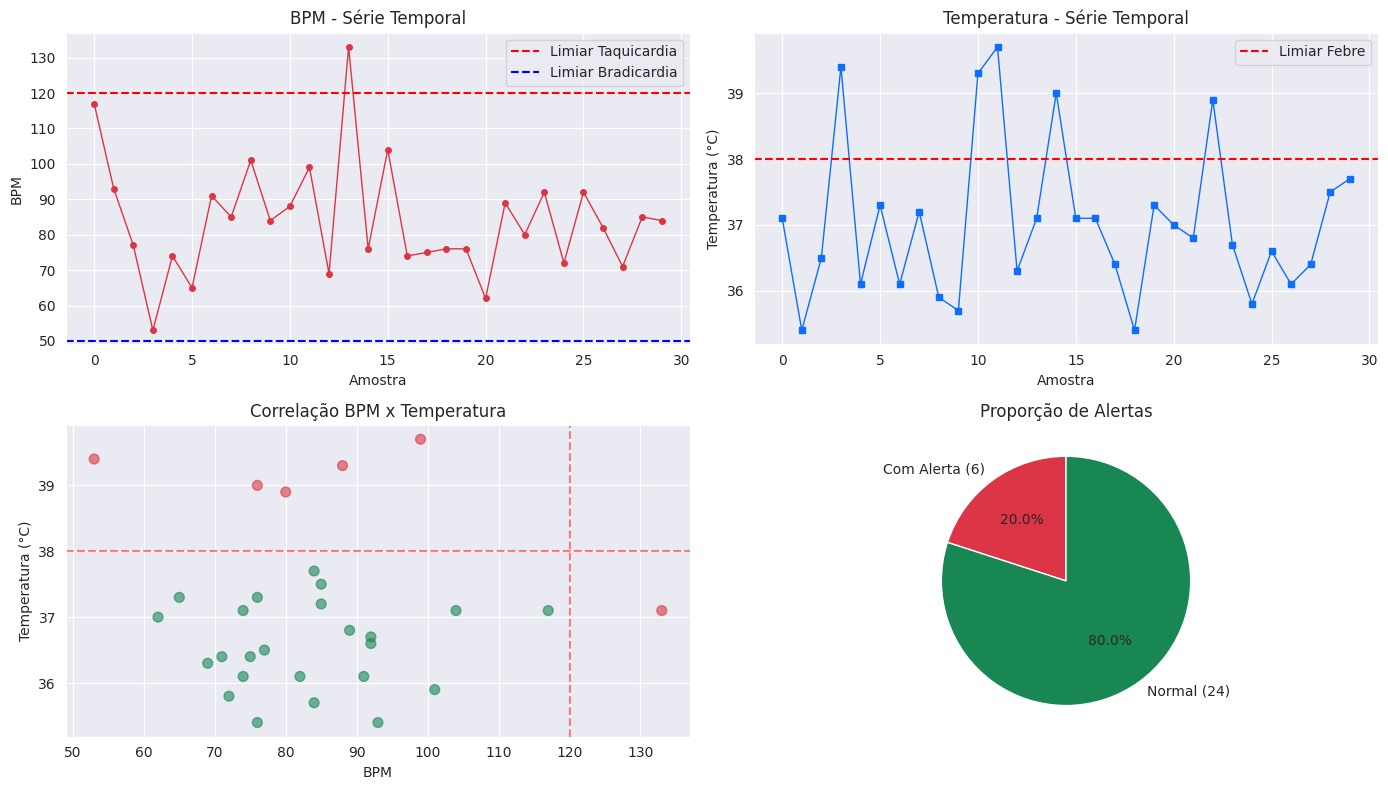

INFO:werkzeug:127.0.0.1 - - [18/May/2026 22:07:30] "GET /api/estatisticas HTTP/1.1" 200 -



📊 ESTATÍSTICAS
Registros: 30
BPM: médio 84.0 | máx 133 | mín 53
Temp: média 37.0°C | máx 39.7°C | mín 35.4°C


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

resp = requests.get(f"{API_URL}/api/sinais")
dados = resp.json()
df = pd.DataFrame(dados)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(range(len(df)), df['bpm'], marker='o', color='#dc3545', linewidth=1, markersize=4)
axes[0,0].axhline(120, color='red', ls='--', label='Limiar Taquicardia')
axes[0,0].axhline(50, color='blue', ls='--', label='Limiar Bradicardia')
axes[0,0].set_title('BPM - Série Temporal')
axes[0,0].set_xlabel('Amostra')
axes[0,0].set_ylabel('BPM')
axes[0,0].legend()

axes[0,1].plot(range(len(df)), df['temperatura'], marker='s', color='#0d6efd', linewidth=1, markersize=4)
axes[0,1].axhline(38, color='red', ls='--', label='Limiar Febre')
axes[0,1].set_title('Temperatura - Série Temporal')
axes[0,1].set_xlabel('Amostra')
axes[0,1].set_ylabel('Temperatura (°C)')
axes[0,1].legend()

cores = ['#dc3545' if (r['bpm']>120 or r['temperatura']>38) else '#198754' for r in dados]
axes[1,0].scatter(df['bpm'], df['temperatura'], c=cores, alpha=0.6, s=50)
axes[1,0].axvline(120, color='red', ls='--', alpha=0.5)
axes[1,0].axhline(38, color='red', ls='--', alpha=0.5)
axes[1,0].set_xlabel('BPM')
axes[1,0].set_ylabel('Temperatura (°C)')
axes[1,0].set_title('Correlação BPM x Temperatura')

tem_alerta = sum(1 for r in dados if r['bpm']>120 or r['temperatura']>38)
sem_alerta = len(dados) - tem_alerta
axes[1,1].pie([tem_alerta, sem_alerta],
              labels=[f'Com Alerta ({tem_alerta})', f'Normal ({sem_alerta})'],
              colors=['#dc3545', '#198754'], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Proporção de Alertas')

plt.tight_layout()
plt.show()

resp_est = requests.get(f"{API_URL}/api/estatisticas")
est = resp_est.json()
print(f"\n📊 ESTATÍSTICAS")
print(f"{'='*35}")
print(f"Registros: {est['total_registros']}")
print(f"BPM: médio {est['bpm_medio']} | máx {est['bpm_max']} | mín {est['bpm_min']}")
print(f"Temp: média {est['temp_media']}°C | máx {est['temp_max']}°C | mín {est['temp_min']}°C")

In [15]:
print("=" * 55)
print("   CARDIOIA - IR ALÉM 1: RELATÓRIO DO FLUXO")
print("=" * 55)
print("""
FLUXO IMPLEMENTADO
─────────────────────────────────────────────
1. DADOS → API REST
   ESP32 (simulado) → POST /api/sinais
   Dados: timestamp, paciente_id, temperatura,
   umidade, bpm, conectado

2. ARMAZENAMENTO
   Dados mantidos em memória (lista Python)
   Consulta via GET /api/sinais

3. VERIFICAÇÃO DE RISCO
   A cada amostra:
   • BPM > 120  → TAQUICARDIA
   • BPM < 50   → BRADICARDIA
   • Temp > 38°C → FEBRE

4. DISPARO DE E-MAIL
   Risco detectado → E-mail simulado enviado
   Para: medico@cardioia.com
   Assunto: 🚨 ALERTA CARDÍACO
   Corpo: dados do paciente + ocorrência

5. DASHBOARD
   • Gráfico BPM ao longo do tempo
   • Gráfico temperatura ao longo do tempo
   • Correlação BPM x Temperatura
   • Proporção de alertas

TECNOLOGIAS
─────────────────────────────────────────────
• Python + Flask → API REST
• requests → Cliente HTTP
• Pandas + Matplotlib → Visualização

MELHORIAS FUTURAS
─────────────────────────────────────────────
• Integração com broker MQTT real
• E-mail real com smtplib + credenciais
• Dashboard em tempo real com WebSockets
• Banco persistente (SQLite/MongoDB)
""")

   CARDIOIA - IR ALÉM 1: RELATÓRIO DO FLUXO

FLUXO IMPLEMENTADO
─────────────────────────────────────────────
1. DADOS → API REST
   ESP32 (simulado) → POST /api/sinais
   Dados: timestamp, paciente_id, temperatura,
   umidade, bpm, conectado

2. ARMAZENAMENTO
   Dados mantidos em memória (lista Python)
   Consulta via GET /api/sinais

3. VERIFICAÇÃO DE RISCO
   A cada amostra:
   • BPM > 120  → TAQUICARDIA
   • BPM < 50   → BRADICARDIA
   • Temp > 38°C → FEBRE

4. DISPARO DE E-MAIL
   Risco detectado → E-mail simulado enviado
   Para: medico@cardioia.com
   Assunto: 🚨 ALERTA CARDÍACO
   Corpo: dados do paciente + ocorrência

5. DASHBOARD
   • Gráfico BPM ao longo do tempo
   • Gráfico temperatura ao longo do tempo
   • Correlação BPM x Temperatura
   • Proporção de alertas

TECNOLOGIAS
─────────────────────────────────────────────
• Python + Flask → API REST
• requests → Cliente HTTP
• Pandas + Matplotlib → Visualização

MELHORIAS FUTURAS
─────────────────────────────────────────────
